In [1]:
# @title Load Data and Libraries

import pandas as pd
import numpy as np
import os

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
np.seterr(divide='ignore', over='ignore', invalid='ignore')

try:
    import google.colab
    REPO_URL = "https://github.com/wtheisen/nd-cse-30124-homeworks.git"

    REPO_PATH = "/content/nd-cse-30124-homeworks"
    L_PATH = "nd-cse-30124-homeworks/evidence/practicum"

    %cd /content/
    !rm -r {REPO_NAME}

    # Clone repo
    if not os.path.exists(REPO_PATH):
        !git clone {REPO_URL}

        # cd into the data folder
        %cd {L_PATH}
        !pwd

except ImportError:
    print(os.getcwd())
    os.chdir("../evidence/practicum")
    # print(os.getcwd())



/Users/wtheisen/Library/CloudStorage/GoogleDrive-wtheisen@nd.edu/My Drive/Artificial Intelligence/CSE 30124 - Introduction to Artificial Intelligence/Homeworks/practicum


In [2]:
# Load Heart Disease dataset
df = pd.read_csv('./heart.csv', na_values='?')

# Print dataset summary
num_samples = df.shape[0]
num_features = df.shape[1] - 1
num_unique_targets = df['target'].nunique()
unique_target_values = df['target'].value_counts()

print(f"Number of samples: {num_samples}")
print(f"Number of features: {num_features}")
print(f"Number of unique target values: {num_unique_targets}")
print("\nUnique target values and their counts:")
print(unique_target_values)

# Check for missing values
df.isnull().sum()

# Fill missing values with the median
df.fillna(df.median(), inplace=True)

Number of samples: 303
Number of features: 13
Number of unique target values: 5

Unique target values and their counts:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

X = df.drop(columns='target')
y = df['target']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

/Users/wtheisen/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def make_loader(X, y, batch_size=32, shuffle=False):
    # Handle pandas DataFrame/Series and NumPy arrays consistently
    X_np = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
    y_np = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

X_train_us, X_test_us, y_train_us, y_test_us = train_test_split(
    X, df['target'], test_size=0.3, random_state=42
)

train_loader_us = make_loader(X_train_us, y_train_us, shuffle=True)
test_loader_us  = make_loader(X_test_us, y_test_us)


X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_scaled, df['target'], test_size=0.3, random_state=42
)

train_loader_u = make_loader(X_train_u, y_train_u, shuffle=True)
test_loader_u  = make_loader(X_test_u, y_test_u)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42
)

train_loader_b = make_loader(X_train_b, y_train_b, shuffle=True)
test_loader_b  = make_loader(X_test_b, y_test_b)


# TODO: Define a simple neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        # LINES: 3
        self.fc1 = nn.Linear(input_size, num_classes)
        

    def forward(self, x):
        # LINES: 4
        out = self.fc1(x)
        return out

# Initialize the model, loss function, and optimizer
input_size = X_train_u.shape[1]
num_classes = len(df['target'].unique())

# TODO: Initialize model, criterion, optimizer, and epochs
# LINES: 4
model = SimpleNN(input_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 100

def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, epochs=100):
    results = []
    for run in range(10):
        # Training loop
        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in train_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Evaluate the model
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

            print(f'Accuracy of the model on the test set: {100 * correct / total:.2f}%')
            results.append(100 * correct / total)

    print(f'Average accuracy over {len(results)} runs: {np.mean(results):.2f}%')

print("Unscaled and Unbalanced Dataset Results:")
train_and_evaluate(model, train_loader_us, test_loader_us, criterion, optimizer)

print('-' * 80)


print("Unbalanced Dataset Results:")
train_and_evaluate(model, train_loader_u, test_loader_u, criterion, optimizer)

print('-' * 80)

print("Balanced Dataset Results:")
train_and_evaluate(model, train_loader_b, test_loader_b, criterion, optimizer)

Unscaled and Unbalanced Dataset Results:
Accuracy of the model on the test set: 59.34%
Accuracy of the model on the test set: 51.65%
Accuracy of the model on the test set: 56.04%
Accuracy of the model on the test set: 53.85%
Accuracy of the model on the test set: 46.15%
Accuracy of the model on the test set: 52.75%
Accuracy of the model on the test set: 51.65%
Accuracy of the model on the test set: 52.75%
Accuracy of the model on the test set: 56.04%
Accuracy of the model on the test set: 56.04%
Average accuracy over 10 runs: 53.63%
--------------------------------------------------------------------------------
Unbalanced Dataset Results:
Accuracy of the model on the test set: 53.85%
Accuracy of the model on the test set: 56.04%
Accuracy of the model on the test set: 57.14%
Accuracy of the model on the test set: 54.95%
Accuracy of the model on the test set: 56.04%
Accuracy of the model on the test set: 56.04%
Accuracy of the model on the test set: 54.95%
Accuracy of the model on the t

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def make_loader(X, y, batch_size=32, shuffle=False):
    # Handle pandas DataFrame/Series and NumPy arrays consistently
    X_np = X.to_numpy() if hasattr(X, "to_numpy") else np.asarray(X)
    y_np = y.to_numpy() if hasattr(y, "to_numpy") else np.asarray(y)

    X_t = torch.tensor(X_np, dtype=torch.float32)
    y_t = torch.tensor(y_np, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

X_train_us, X_test_us, y_train_us, y_test_us = train_test_split(
    X, df['target'], test_size=0.3, random_state=42
)

train_loader_us = make_loader(X_train_us, y_train_us, shuffle=True)
test_loader_us  = make_loader(X_test_us, y_test_us)


X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_scaled, df['target'], test_size=0.3, random_state=42
)

train_loader_u = make_loader(X_train_u, y_train_u, shuffle=True)
test_loader_u  = make_loader(X_test_u, y_test_u)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=42
)

train_loader_b = make_loader(X_train_b, y_train_b, shuffle=True)
test_loader_b  = make_loader(X_test_b, y_test_b)



# TODO: Define a simple neural network
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        # LINES: 3
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
        

    def forward(self, x):
        # LINES: 4
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Initialize the model, loss function, and optimizer
input_size = X_train_u.shape[1]
hidden_size = 128
num_classes = len(df['target'].unique())

# TODO: Initialize model, criterion, optimizer, and epochs
# LINES: 4
model = SimpleNN(input_size, hidden_size, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 100

def train_and_evaluate(model, train_loader, test_loader, criterion, optimizer, epochs=100):
    results = []
    for run in range(10):
        # Training loop
        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in train_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Evaluate the model
        model.eval()
        with torch.no_grad():
            correct = 0
            total = 0
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()

            print(f'Accuracy of the model on the test set: {100 * correct / total:.2f}%')
            results.append(100 * correct / total)

    print(f'Average accuracy over {len(results)} runs: {np.mean(results):.2f}%')

print("Unscaled and Unbalanced Dataset Results:")
train_and_evaluate(model, train_loader_us, test_loader_us, criterion, optimizer)

print('-' * 80)


print("Unbalanced Dataset Results:")
train_and_evaluate(model, train_loader_u, test_loader_u, criterion, optimizer)

print('-' * 80)

print("Balanced Dataset Results:")
train_and_evaluate(model, train_loader_b, test_loader_b, criterion, optimizer)

Unscaled and Unbalanced Dataset Results:
Accuracy of the model on the test set: 45.05%
Accuracy of the model on the test set: 47.25%
Accuracy of the model on the test set: 57.14%
Accuracy of the model on the test set: 53.85%
Accuracy of the model on the test set: 52.75%
Accuracy of the model on the test set: 49.45%
Accuracy of the model on the test set: 47.25%
Accuracy of the model on the test set: 47.25%
Accuracy of the model on the test set: 43.96%
Accuracy of the model on the test set: 43.96%
Average accuracy over 10 runs: 48.79%
--------------------------------------------------------------------------------
Unbalanced Dataset Results:
Accuracy of the model on the test set: 50.55%
Accuracy of the model on the test set: 50.55%
Accuracy of the model on the test set: 49.45%
Accuracy of the model on the test set: 50.55%
Accuracy of the model on the test set: 50.55%
Accuracy of the model on the test set: 50.55%
Accuracy of the model on the test set: 50.55%
Accuracy of the model on the t

/var/folders/m2/mvxnhj_x401c37lhdf_t18sr0000gs/T/ipykernel_10284/1893253412.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([results_by_combo[k] for k in labels], labels=labels, patch_artist=True)


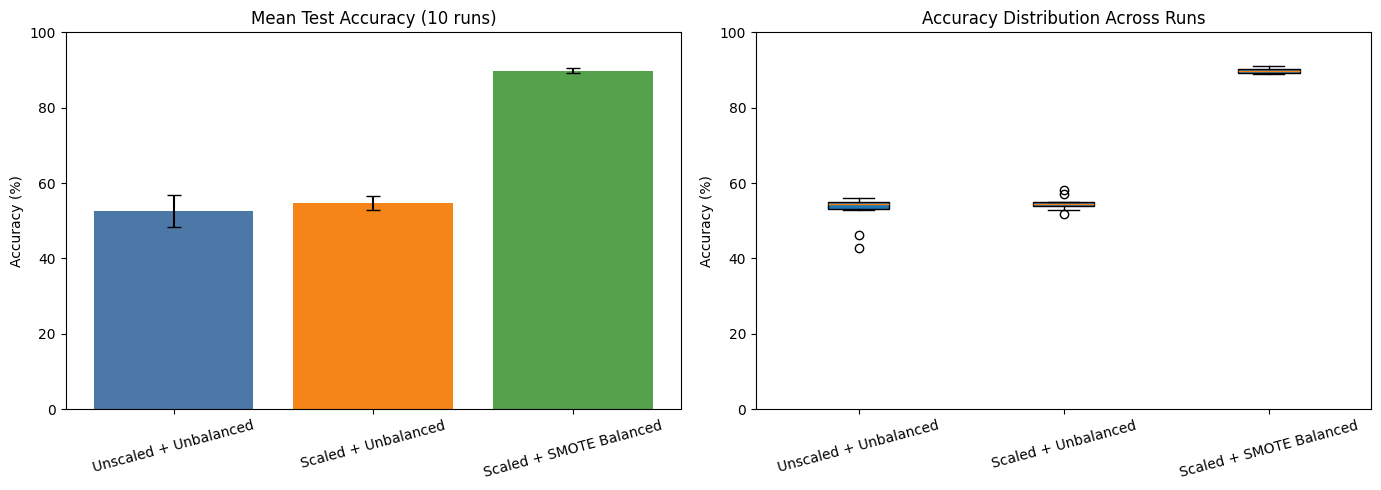

Unscaled + Unbalanced: mean=52.53%, std=4.16%
Scaled + Unbalanced: mean=54.62%, std=1.84%
Scaled + SMOTE Balanced: mean=89.76%, std=0.68%


In [13]:
# Plot comparison of NN performance across dataset setups
import inspect
import matplotlib.pyplot as plt


def build_model(input_size, num_classes):
    """Create a fresh model, handling either SimpleNN signature version."""
    sig = inspect.signature(SimpleNN.__init__)
    if "hidden_size" in sig.parameters:
        hs = hidden_size if "hidden_size" in globals() else 128
        return SimpleNN(input_size, hs, num_classes)
    return SimpleNN(input_size, num_classes)


def run_experiment(train_loader, test_loader, runs=10):
    run_acc = []
    for _ in range(runs):
        model_local = build_model(input_size, num_classes)
        optimizer_local = optim.Adam(model_local.parameters(), lr=0.005)

        # Train
        for _ in range(epochs):
            model_local.train()
            for X_batch, y_batch in train_loader:
                outputs = model_local(X_batch)
                loss = criterion(outputs, y_batch)
                optimizer_local.zero_grad()
                loss.backward()
                optimizer_local.step()

        # Evaluate
        model_local.eval()
        with torch.no_grad():
            correct, total = 0, 0
            for X_batch, y_batch in test_loader:
                outputs = model_local(X_batch)
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        run_acc.append(100 * correct / total)

    return run_acc


results_by_combo = {
    "Unscaled + Unbalanced": run_experiment(train_loader_us, test_loader_us),
    "Scaled + Unbalanced": run_experiment(train_loader_u, test_loader_u),
    "Scaled + SMOTE Balanced": run_experiment(train_loader_b, test_loader_b),
}

labels = list(results_by_combo.keys())
means = [np.mean(results_by_combo[k]) for k in labels]
stds = [np.std(results_by_combo[k]) for k in labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: mean accuracy with standard deviation
axes[0].bar(labels, means, yerr=stds, capsize=5, color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Mean Test Accuracy (10 runs)")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=15)

# Box plot: run-to-run spread
axes[1].boxplot([results_by_combo[k] for k in labels], labels=labels, patch_artist=True)
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy Distribution Across Runs")
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

for name in labels:
    print(f"{name}: mean={np.mean(results_by_combo[name]):.2f}%, std={np.std(results_by_combo[name]):.2f}%")

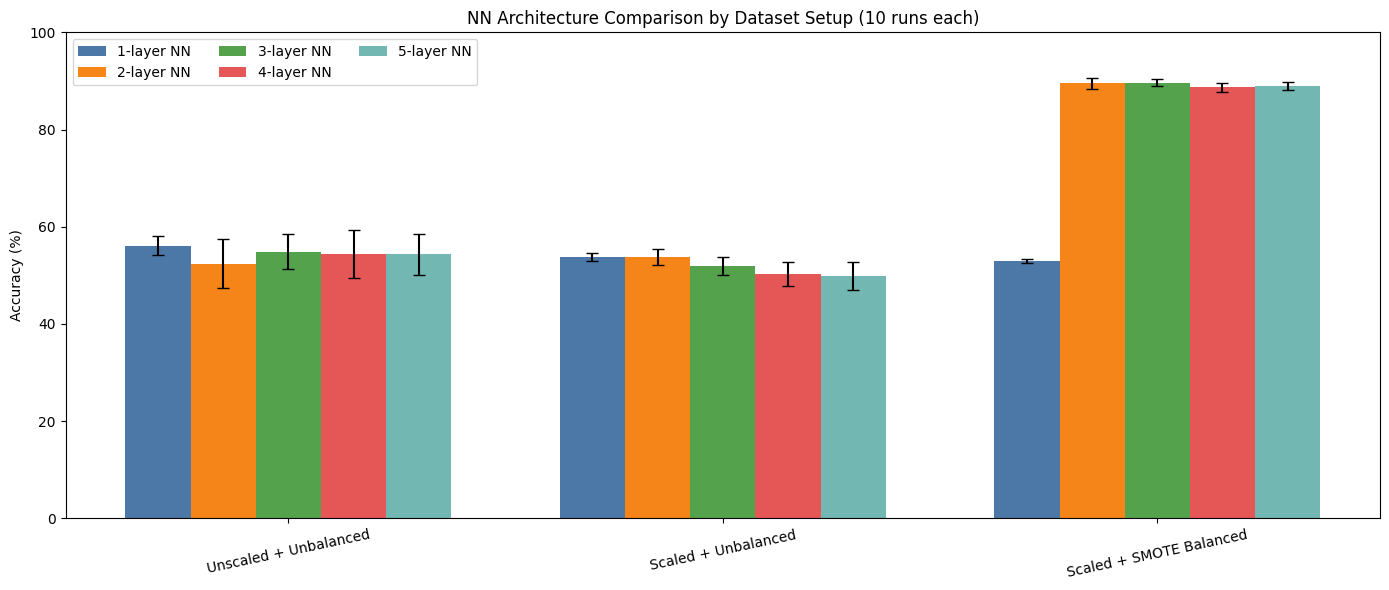

Architecture comparison (mean ± std):
- Unscaled + Unbalanced
    1-layer: 56.04% ± 1.97%
    2-layer: 52.42% ± 5.11%
    3-layer: 54.84% ± 3.63%
    4-layer: 54.40% ± 5.02%
    5-layer: 54.29% ± 4.26%
- Scaled + Unbalanced
    1-layer: 53.74% ± 0.77%
    2-layer: 53.74% ± 1.59%
    3-layer: 51.98% ± 1.84%
    4-layer: 50.33% ± 2.45%
    5-layer: 49.89% ± 2.92%
- Scaled + SMOTE Balanced
    1-layer: 52.93% ± 0.47%
    2-layer: 89.51% ± 1.07%
    3-layer: 89.67% ± 0.71%
    4-layer: 88.70% ± 0.91%
    5-layer: 88.90% ± 0.83%


In [18]:
# Compare 1- to 5-layer NNs across all dataset setups
import matplotlib.pyplot as plt


class MultiLayerNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, num_layers):
        super().__init__()
        layers = []

        if num_layers == 1:
            layers.append(nn.Linear(input_size, num_classes))
        else:
            # Input -> first hidden
            layers.extend([nn.Linear(input_size, hidden_size), nn.ReLU()])
            # Additional hidden layers
            for _ in range(num_layers - 2):
                layers.extend([nn.Linear(hidden_size, hidden_size), nn.ReLU()])
            # Last hidden -> output
            layers.append(nn.Linear(hidden_size, num_classes))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_architecture_experiment(model_builder, train_loader, test_loader, runs=10):
    accs = []
    for _ in range(runs):
        model_local = model_builder()
        optimizer_local = optim.Adam(model_local.parameters(), lr=0.005)

        # train
        for _ in range(epochs):
            model_local.train()
            for X_batch, y_batch in train_loader:
                outputs = model_local(X_batch)
                loss = criterion(outputs, y_batch)
                optimizer_local.zero_grad()
                loss.backward()
                optimizer_local.step()

        # evaluate
        model_local.eval()
        with torch.no_grad():
            correct, total = 0, 0
            for X_batch, y_batch in test_loader:
                outputs = model_local(X_batch)
                _, predicted = torch.max(outputs.data, 1)
                total += y_batch.size(0)
                correct += (predicted == y_batch).sum().item()
        accs.append(100 * correct / total)

    return accs


# Derive dimensions from current heart-data tensors to avoid stale globals
input_size_local = train_loader_us.dataset.tensors[0].shape[1]
num_classes_local = len(np.unique(train_loader_us.dataset.tensors[1].numpy()))

hidden_size_local = 128
architectures = [1]
setups = [
    ("Unscaled + Unbalanced", train_loader_us, test_loader_us),
    ("Scaled + Unbalanced", train_loader_u, test_loader_u),
    ("Scaled + SMOTE Balanced", train_loader_b, test_loader_b),
]

all_results = {}
for setup_name, tr_loader, te_loader in setups:
    for n_layers in architectures:
        all_results[(f"{n_layers}-layer", setup_name)] = run_architecture_experiment(
            lambda nl=n_layers: MultiLayerNN(input_size_local, hidden_size_local, num_classes_local, nl),
            tr_loader,
            te_loader,
        )

# Grouped bar chart (mean +/- std)
labels = [s[0] for s in setups]
x = np.arange(len(labels))
width = 0.15
offsets = np.linspace(-2 * width, 2 * width, len(architectures))
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756", "#72B7B2"]

plt.figure(figsize=(14, 6))
for i, n_layers in enumerate(architectures):
    means = [np.mean(all_results[(f"{n_layers}-layer", name)]) for name in labels]
    stds = [np.std(all_results[(f"{n_layers}-layer", name)]) for name in labels]
    plt.bar(
        x + offsets[i],
        means,
        width,
        yerr=stds,
        capsize=4,
        label=f"{n_layers}-layer NN",
        color=colors[i],
    )

plt.xticks(x, labels, rotation=12)
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.title("NN Architecture Comparison by Dataset Setup (10 runs each)")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

# Print table-like summary
print("Architecture comparison (mean ± std):")
for name in labels:
    print(f"- {name}")
    for n_layers in architectures:
        m = np.mean(all_results[(f"{n_layers}-layer", name)])
        s = np.std(all_results[(f"{n_layers}-layer", name)])
        print(f"    {n_layers}-layer: {m:.2f}% ± {s:.2f}%")